<a href="https://colab.research.google.com/github/sidms24/AML/blob/main/notebooks/seq_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Processing Pipeline

**Aim:** Download, align, trim, and package influenza HA sequences into a HuggingFace dataset with proper season assignment.


**Pipeline:**
```
Raw FASTA (NCBI) → MAFFT alignment → coverage trimming → accession date parsing
    → MMWR season assignment → HuggingFace Dataset (with year, month, season fields)
```

In [8]:
# mafft for multiple sequence alignment, biopython for FASTA parsing
!apt-get update -y -qq
!apt-get install -y -qq mafft > /dev/null 2>&1
!pip install -q biopython datasets huggingface_hub

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO, AlignIO
from tqdm import tqdm

# force plain text progress bars before importing HF libraries
import tqdm.auto, tqdm.std
tqdm.auto.tqdm = tqdm.std.tqdm
MIN_YEAR = 2009

TEMPORAL_CUTOFF = 2020
from datasets import Dataset, DatasetDict
from huggingface_hub import login, upload_file
from google.colab import userdata

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

## Step 1: Download Raw Sequences

We download the unaligned FASTA files from HuggingFace. These contain H1N1 ($∼$25.6k) and H3N2 ($∼$36.2k) HA nucleotide sequences originally sourced from NCBI.

In [10]:
!wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/data/sequences_h1n1.fasta?download=true -O sequences_h1n1.fasta
!wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/data/sequences_h3n2.fasta?download=true -O sequences_h3n2.fasta
print("Downloaded raw FASTA files")

Downloaded raw FASTA files


In [11]:
def assign_season(year, month=None):
    """we use month to properly assign sequences to flu seasons,
    since flu seasons run Oct-Sep not Jan-Dec"""
    if month is not None and month >= 10:  # Oct-Dec = start of new season
        return f"{year}-{str(year + 1)[-2:]}"
    else:  # Jan-Sep or unknown month
        return f"{year - 1}-{str(year)[-2:]}"

def parse_accession_metadata(csv_path):
    """parses the accession CSV, extracts year + month, assigns proper seasons"""
    df = pd.read_csv(csv_path)
    dates = pd.to_datetime(df['Collection_Date'], format='mixed', errors='coerce')

    df['year'] = dates.dt.year.astype('Int64')
    df['month'] = dates.dt.month.astype('Int64')

    # some Collection_Date entries are year-only (e.g. "2018") which
    # pd.to_datetime parses as Jan 1st. We detect these so we know
    # when the month is real vs just a default
    year_only = df['Collection_Date'].astype(str).str.strip().str.match(r'^\d{4}$')
    df.loc[year_only, 'month'] = pd.NA
    df['has_month'] = ~year_only & df['month'].notna()

    # assign seasons - we use month when we have it, otherwise
    # fall back to the old year-only method (assumes Jan-Sep)
    df['season'] = df.apply(
        lambda row: assign_season(
            int(row['year']),
            int(row['month']) if pd.notna(row['month']) else None
        ) if pd.notna(row['year']) else None,
        axis=1
    )

    return df


# Global Sequences (All Geographies)

**Why:** We train the generative models used in the final report (Conv1D VAE and Transformer VAE) on **global** HA sequences to learn a richer latent manifold — antigenic drift is a property of the virus, not geography. At inference time we extract latents from **North America-only** sequences to compute drift scores aligned with US CDC surveillance.

The global FASTA files were downloaded from NCBI Virus with the same filters as before (complete assembly, human host, hemagglutinin protein) but **without** the Geographic Region = North America restriction. The FASTA header includes `Geographic_Region` and `Collection_Date` fields so we can filter at inference time.

**Header format:** `>Accession|GenBank_Title|Geographic_Region|Collection_Date`

In [ ]:
# geographic region filter removed so the model sees worldwide antigenic diversity
# header format: >Accession|GenBank_Title|Geographic_Region|Collection_Date

!wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/data/sequences_h1n1_global.fasta -O global_sequences_h1n1.fasta
!wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/data/sequences_h3n2_global.fasta -O global_sequences_h3n2.fasta
print("Downloaded global FASTA files")

### Align & Trim Global Sequences

Same MAFFT + coverage trimming pipeline as the North America data. Set `SKIP_GLOBAL_ALIGNMENT = True` if pre-aligned files are already on HuggingFace.

  global_sequences_h1n1.fasta: done!                                        
  global_sequences_h3n2.fasta: done!                                        


/tmp/ipykernel_13736/1117471812.py:45: DeprecationWarning: Converting `np.character` to a dtype is deprecated. The current result is `np.dtype(np.str_)` which is not strictly correct. Note that `np.character` is generally deprecated and 'S1' should be used.
  align_array = np.array([list(rec) for rec in alignment], np.character)


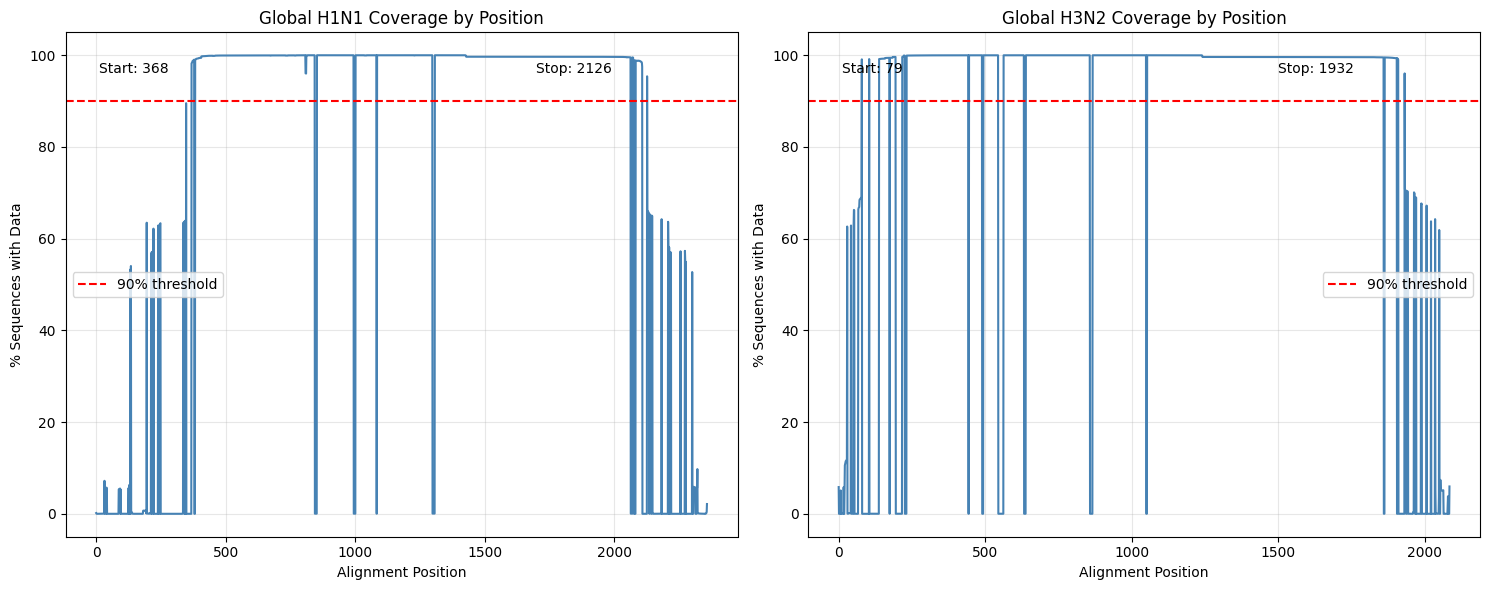

Global H1N1: trimmed to positions 368-2127 -> length 1759
Global H3N2: trimmed to positions 79-1933 -> length 1854


In [13]:
SKIP_GLOBAL_ALIGNMENT = False

import subprocess, re

def run_mafft(input_fasta, output_fasta):
  """runs mafft --parttree with live progress updates"""
  cmd = f"mafft --parttree --thread -1 {input_fasta}"
  with open(output_fasta, "w") as out:
      proc = subprocess.Popen(cmd.split(), stdout=out,
                              stderr=subprocess.PIPE, text=True)

      last_printed = 0
      for line in proc.stderr:
          m = re.search(r'Leaf\s+(\d+)\s*/\s*(\d+)', line)
          if m:
              current, total = int(m.group(1)), int(m.group(2))
              if current - last_printed >= total // 20:
                  pct = current / total * 100
                  print(f"\r  {input_fasta}: {current:,}/{total:,} ({pct:.0f}%)", end="", flush=True)
                  last_printed = current

      proc.wait()
      if proc.returncode != 0:
          print(f"\n  MAFFT failed on {input_fasta} — check input")
      else:
          print(f"\r  {input_fasta}: done!{' ' * 40}")

if not SKIP_GLOBAL_ALIGNMENT:
    run_mafft('global_sequences_h1n1.fasta', 'aligned_global_h1n1.fasta')
    run_mafft('global_sequences_h3n2.fasta', 'aligned_global_h3n2.fasta')
else:
    !wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/data/aligned_global_h1n1.fasta?download=true -O aligned_global_h1n1.fasta
    !wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/data/aligned_global_h3n2.fasta?download=true -O aligned_global_h3n2.fasta
    print("Downloaded pre-aligned global FASTAs")

# trim using same 90% coverage threshold
fig, axes = plt.subplots(figsize=(15, 6), nrows=1, ncols=2)

global_cut_points = {}
global_subtypes = [('H1N1', 'aligned_global_h1n1.fasta'),
                   ('H3N2', 'aligned_global_h3n2.fasta')]

for i, (subtype, filename) in enumerate(global_subtypes):
    alignment = AlignIO.read(filename, "fasta")
    align_array = np.array([list(rec) for rec in alignment], np.character)
    is_data = (align_array != b'-')
    coverage = np.mean(is_data, axis=0) * 100
    valid_indices = np.where(coverage > 90)[0]

    global_cut_points[subtype] = (valid_indices[0], valid_indices[-1] + 1)

    axes[i].plot(coverage, color='steelblue')
    axes[i].axhline(y=90, color='r', linestyle='--', label='90% threshold')
    axes[i].set_title(f'Global {subtype} Coverage by Position')
    axes[i].set_xlabel('Alignment Position')
    axes[i].set_ylabel('% Sequences with Data')
    axes[i].annotate(f"Start: {valid_indices[0]}", xy=(0.05, 0.92), xycoords='axes fraction')
    axes[i].annotate(f"Stop: {valid_indices[-1]}", xy=(0.7, 0.92), xycoords='axes fraction')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

for subtype, (start, stop) in global_cut_points.items():
    filename = f"aligned_global_{subtype.lower()}.fasta"
    alignment = AlignIO.read(filename, "fasta")
    trimmed = alignment[:, start:stop]
    output = f"trimmed_global_{subtype.lower()}.fasta"
    AlignIO.write(trimmed, output, "fasta")
    print(f"Global {subtype}: trimmed to positions {start}-{stop} -> length {stop - start}")

### Parse Global Metadata from FASTA Headers

The global FASTA headers contain `Geographic_Region` and `Collection_Date` embedded in the definition line. We parse these directly instead of needing a separate accession CSV.

### Build & Upload Global Dataset

Same `build_dataset` function as before, adapted for global metadata. The `region` field is preserved so we can filter to North America at inference time for drift scoring.

In [14]:
def parse_global_fasta_metadata(fasta_path):
    """parses metadata directly from the NCBI Virus custom FASTA headers.
    expected header: >Accession|GenBank_Title|Geographic_Region|Collection_Date"""
    records = []
    for record in tqdm.tqdm(SeqIO.parse(fasta_path, 'fasta'), desc=os.path.basename(fasta_path)):
        # the description has the full header line; split on pipe
        parts = record.description.split('|')
        accession = parts[0].strip()
        region = parts[2].strip() if len(parts) > 2 else 'Unknown'
        date_str = parts[3].strip() if len(parts) > 3 else ''

        # parse date — handles YYYY-MM-DD, YYYY-MM, and YYYY
        year, month, has_month = None, None, False
        if date_str:
            date_parts = date_str.split('-')
            try:
                year = int(date_parts[0])
                if len(date_parts) >= 2:
                    month = int(date_parts[1])
                    has_month = True
            except ValueError:
                pass

        season = assign_season(year, month if has_month else None) if year else None

        records.append({
            'Accession': accession,
            'region': region,
            'year': year,
            'month': month if has_month else None,
            'has_month': has_month,
            'season': season,
        })

    df = pd.DataFrame(records)
    return df

global_h1n1_meta = parse_global_fasta_metadata('trimmed_global_h1n1.fasta')
global_h3n2_meta = parse_global_fasta_metadata('trimmed_global_h3n2.fasta')


trimmed_global_h1n1.fasta: 32463it [00:00, 85906.63it/s]
trimmed_global_h3n2.fasta: 49638it [00:00, 82472.40it/s]


In [15]:
def build_global_dataset(fasta_path, metadata_df, subtype, split_mode='random'):
    """builds a HuggingFace dataset from global sequences, preserving the region
    field so we can filter to North America at drift-scoring time"""

    acc_to_meta = {}
    for _, row in metadata_df.iterrows():
        if pd.notna(row.get('year')):
            acc_to_meta[row['Accession']] = {
                'year': int(row['year']),
                'month': int(row['month']) if pd.notna(row.get('month')) else -1,
                'season': row['season'],
                'has_month': bool(row['has_month']),
                'region': row.get('region', 'Unknown'),
            }

    data = {'id': [], 'sequence': [], 'year': [], 'month': [],
            'season': [], 'has_month': [], 'subtype': [], 'region': []}
    skipped = 0

    for record in tqdm.tqdm(SeqIO.parse(fasta_path, 'fasta'), desc=subtype):
        acc = record.id.split('|')[0].strip()
        if acc not in acc_to_meta:
            skipped += 1
            continue
        meta = acc_to_meta[acc]
        if meta['year'] < MIN_YEAR:
            continue

        data['id'].append(acc)
        data['sequence'].append(str(record.seq))
        data['year'].append(meta['year'])
        data['month'].append(meta['month'])
        data['season'].append(meta['season'])
        data['has_month'].append(meta['has_month'])
        data['subtype'].append(subtype)
        data['region'].append(meta['region'])

    print(f"Global {subtype}: {len(data['id'])} sequences kept, {skipped} had no metadata match")

    full_dataset = Dataset.from_dict(data)

    if split_mode == 'temporal':
        train_idx = [i for i, y in enumerate(data['year']) if y < TEMPORAL_CUTOFF]
        test_idx = [i for i, y in enumerate(data['year']) if y >= TEMPORAL_CUTOFF]
        dataset_dict = DatasetDict({
            'train': full_dataset.select(train_idx),
            'test': full_dataset.select(test_idx)
        })
        print(f"  Temporal split (cutoff {TEMPORAL_CUTOFF}): {len(train_idx)} train, {len(test_idx)} test")
    else:
        dataset_dict = full_dataset.train_test_split(test_size=0.2, seed=42)
        print(f"  Random split: {len(dataset_dict['train'])} train, {len(dataset_dict['test'])} test")

    return dataset_dict

# build global datasets — random split for model training
global_h1n1 = build_global_dataset('trimmed_global_h1n1.fasta', global_h1n1_meta, 'H1N1', split_mode='random')
global_h3n2 = build_global_dataset('trimmed_global_h3n2.fasta', global_h3n2_meta, 'H3N2', split_mode='random')

# also build temporal splits for completeness
global_h1n1_temp = build_global_dataset('trimmed_global_h1n1.fasta', global_h1n1_meta, 'H1N1', split_mode='temporal')
global_h3n2_temp = build_global_dataset('trimmed_global_h3n2.fasta', global_h3n2_meta, 'H3N2', split_mode='temporal')

H1N1: 32463it [00:00, 84749.42it/s]


Global H1N1: 31222 sequences kept, 0 had no metadata match
  Random split: 24977 train, 6245 test


H3N2: 49638it [00:00, 75461.07it/s]


Global H3N2: 46656 sequences kept, 0 had no metadata match
  Random split: 37324 train, 9332 test


H1N1: 32463it [00:00, 86447.69it/s]


Global H1N1: 31222 sequences kept, 0 had no metadata match
  Temporal split (cutoff 2020): 13483 train, 17739 test


H3N2: 49638it [00:00, 83889.36it/s]


Global H3N2: 46656 sequences kept, 0 had no metadata match
  Temporal split (cutoff 2020): 19144 train, 27512 test


In [ ]:
# _global suffix configs are for model training; the original NA-only configs remain for drift scoring
global_h1n1.push_to_hub('sidms/AML', config_name='H1N1_global')
global_h3n2.push_to_hub('sidms/AML', config_name='H3N2_global')

global_h1n1_temp.push_to_hub('sidms/AML', config_name='H1N1_global_temporal')
global_h3n2_temp.push_to_hub('sidms/AML', config_name='H3N2_global_temporal')

for f in ['trimmed_global_h1n1.fasta', 'trimmed_global_h3n2.fasta']:
    upload_file(path_or_fileobj=f, repo_id='sidms/AML',
                path_in_repo=f'data/{f}', repo_type='dataset')

print("Global data uploaded to HuggingFace")

In [17]:
drift_datasets = {}

for subtype, global_meta, fasta in [
    ('H1N1', global_h1n1_meta, 'trimmed_global_h1n1.fasta'),
    ('H3N2', global_h3n2_meta, 'trimmed_global_h3n2.fasta')
]:
    us_mask = global_meta['region'].str.startswith('USA', na=False)
    meta = global_meta[us_mask].copy()
    acc_to_meta = {}
    for _, row in meta.iterrows():
        if pd.notna(row.get('year')):
            acc_to_meta[row['Accession']] = {
                'year': int(row['year']),
                'month': int(row['month']) if pd.notna(row.get('month')) else -1,
                'season': row['season'],
                'has_month': bool(row['has_month']),
            }

    data = {'id': [], 'sequence': [], 'year': [], 'month': [],
            'season': [], 'has_month': [], 'subtype': []}

    total, kept = 0, 0
    for record in tqdm.tqdm(SeqIO.parse(fasta, 'fasta'), desc=f'{subtype} USA filter'):
        acc = record.id.split('|')[0].strip()
        total += 1
        if acc not in acc_to_meta:
            continue
        m = acc_to_meta[acc]
        if m['year'] < MIN_YEAR:
            continue
        data['id'].append(acc)
        data['sequence'].append(str(record.seq))
        data['year'].append(m['year'])
        data['month'].append(m['month'])
        data['season'].append(m['season'])
        data['has_month'].append(m['has_month'])
        data['subtype'].append(subtype)
        kept += 1

    ds = Dataset.from_dict(data)
    drift_datasets[subtype] = ds
    ds.push_to_hub('sidms/AML', config_name=f'{subtype}_drift')
    print(f"{subtype} drift set: {kept}/{total} global sequences are USA ({kept/total*100:.1f}%)")

h1n1_drift = drift_datasets['H1N1']
h3n2_drift = drift_datasets['H3N2']

H1N1 USA filter: 32463it [00:00, 85124.01it/s]
Creating parquet from Arrow format: 100%|██████████| 26/26 [00:00<00:00, 360.82ba/s]
Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|██████████| 5.26MB / 5.26MB            

Processing Files (1 / 1)      : 100%|██████████| 5.26MB / 5.26MB,   ???B/s  

                              : 100%|██████████| 5.26MB / 5.26MB            

Processing Files (1 / 1)      : 100%|██████████| 5.26MB / 5.26MB,  0.00B/s  
New Data Upload               : |          |  0.00B /  0.00B,  0.00B/s  
                              : 100%|██████████| 5.26MB / 5.26MB            
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.37 shards/s]


H1N1 drift set: 25760/32463 global sequences are USA (79.4%)


H3N2 USA filter: 49638it [00:00, 81479.74it/s]
Creating parquet from Arrow format: 100%|██████████| 39/39 [00:00<00:00, 389.80ba/s]
Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|██████████| 6.31MB / 6.31MB            

Processing Files (1 / 1)      : 100%|██████████| 6.31MB / 6.31MB,   ???B/s  

                              : 100%|██████████| 6.31MB / 6.31MB            

Processing Files (1 / 1)      : 100%|██████████| 6.31MB / 6.31MB,  0.00B/s  
New Data Upload               : |          |  0.00B /  0.00B,  0.00B/s  
                              : 100%|██████████| 6.31MB / 6.31MB            
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.30 shards/s]


H3N2 drift set: 38109/49638 global sequences are USA (76.8%)


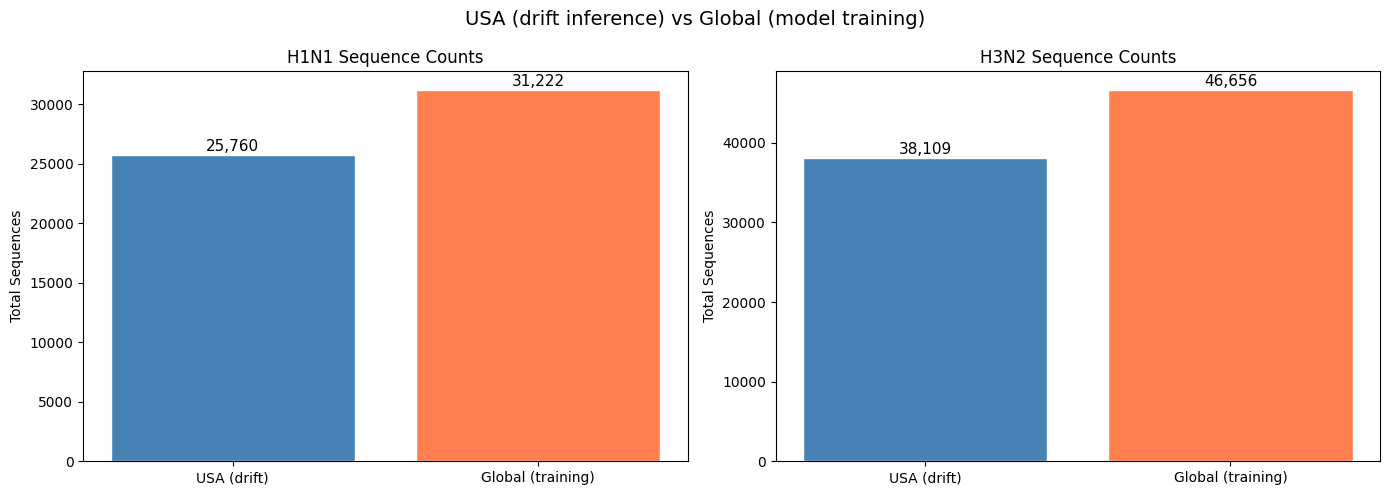

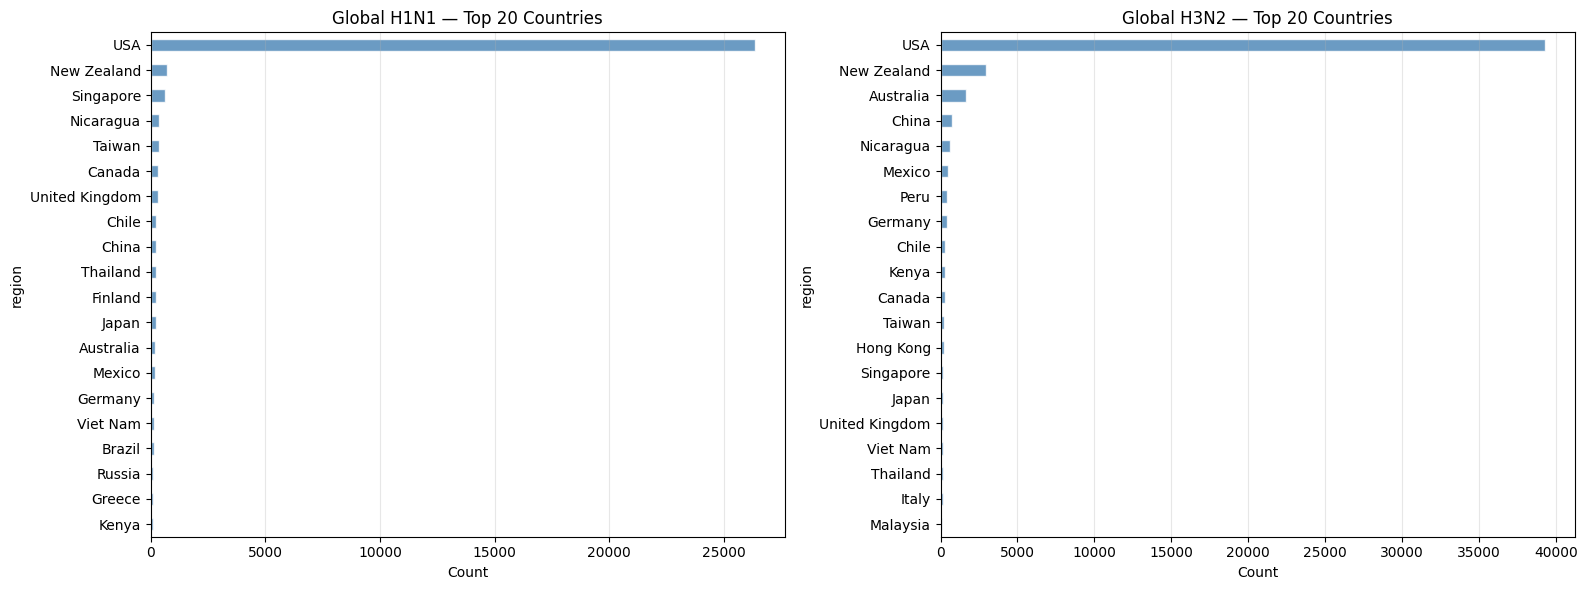

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, g_ds, d_ds) in zip(axes, [
    ('H1N1', global_h1n1, h1n1_drift),
    ('H3N2', global_h3n2, h3n2_drift)
]):
    global_n = len(g_ds['train']) + len(g_ds['test'])
    usa_n = len(d_ds)
    bars = ax.bar(['USA (drift)', 'Global (training)'], [usa_n, global_n],
                  color=['steelblue', 'coral'], edgecolor='white')
    ax.set_title(f'{name} Sequence Counts')
    ax.set_ylabel('Total Sequences')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11)

plt.suptitle('USA (drift inference) vs Global (model training)', fontsize=14)
plt.tight_layout()
plt.show()

# geographic breakdown — group by country (first part before colon)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, meta) in zip(axes, [('H1N1', global_h1n1_meta), ('H3N2', global_h3n2_meta)]):
    countries = meta['region'].str.split(':').str[0].str.strip()
    country_counts = countries.value_counts().head(20)
    country_counts.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'Global {name} — Top 20 Countries')
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

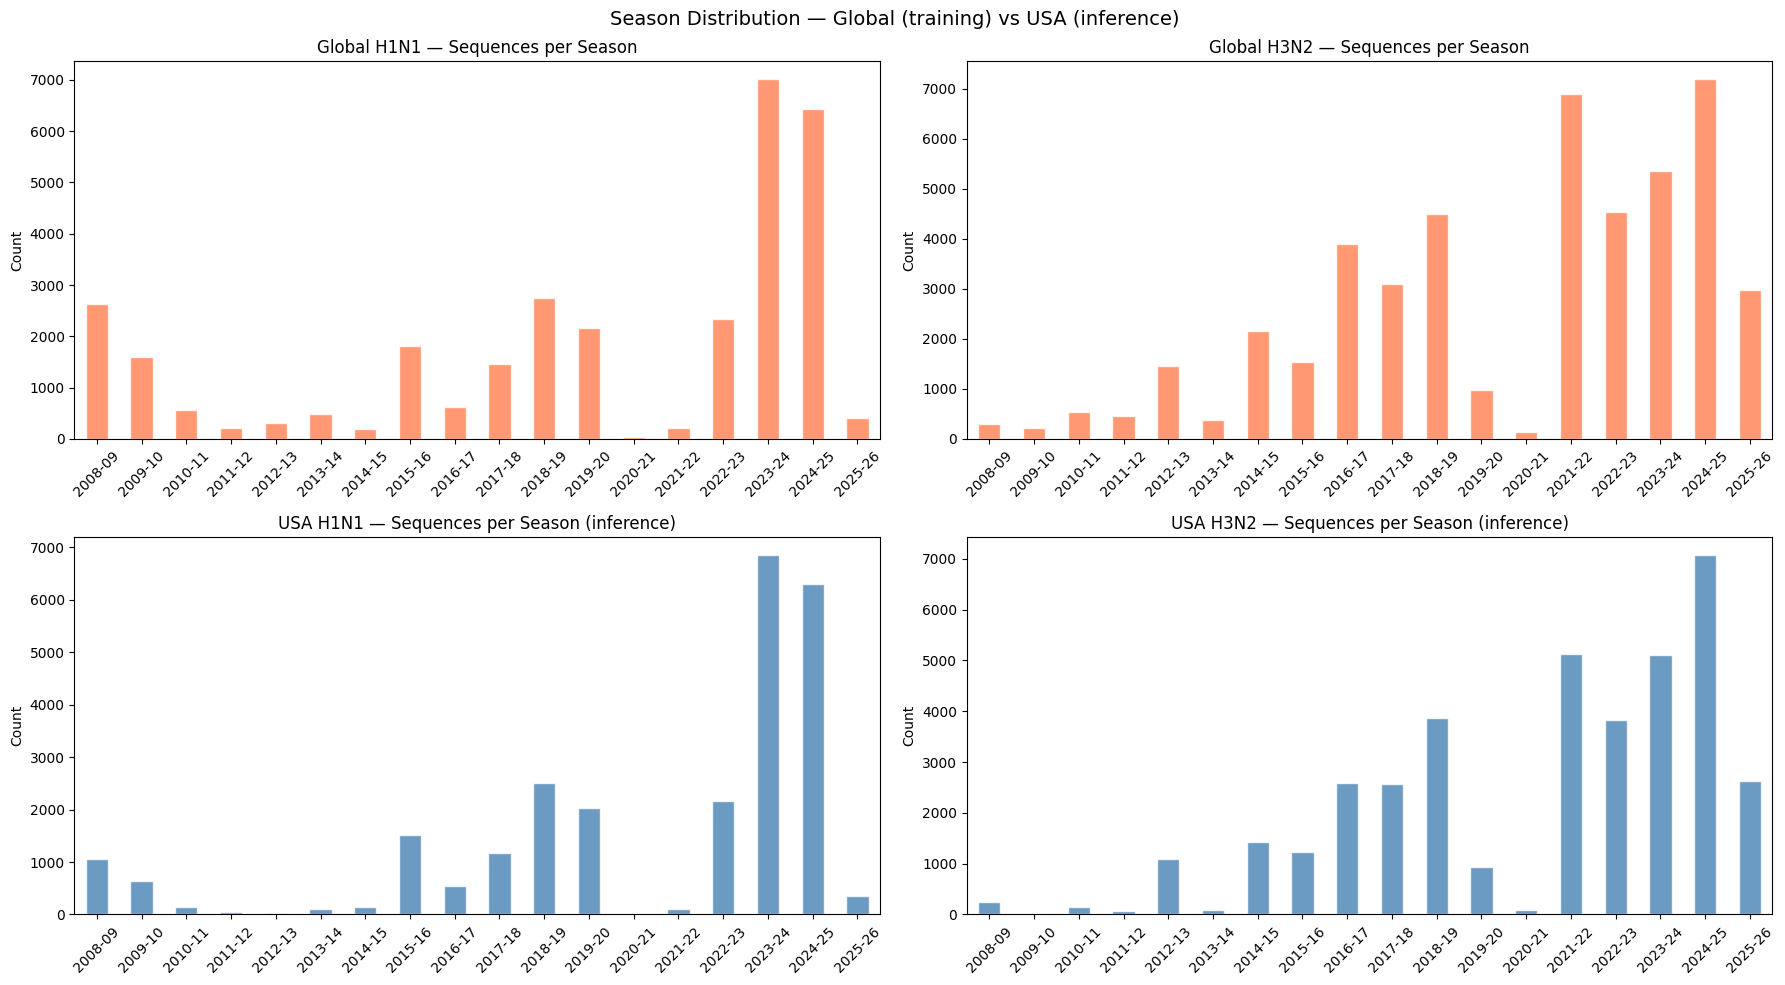

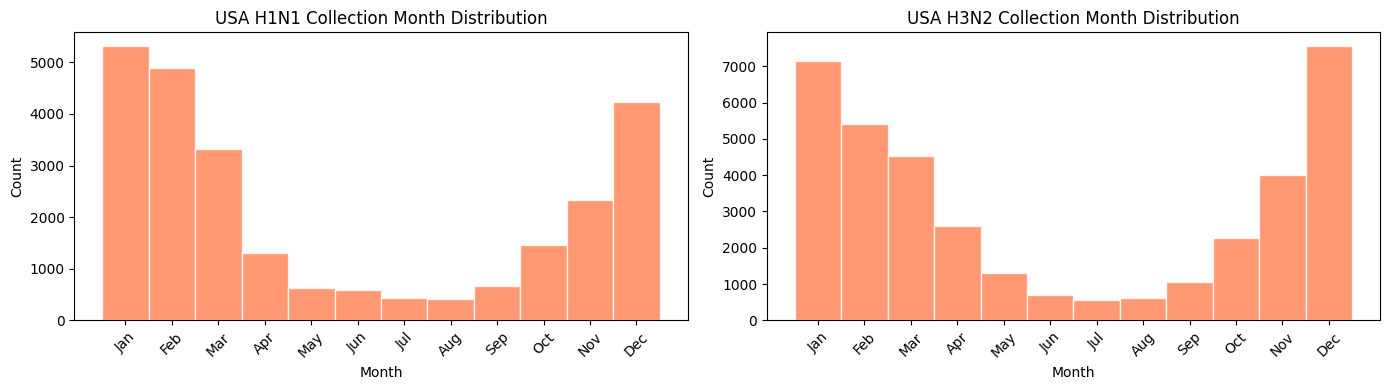

USA H1N1: 22881/25590 sequences collected Oct-Apr (89.4%)
USA H3N2: 33540/37790 sequences collected Oct-Apr (88.8%)


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for col, (name, g_ds, d_ds) in enumerate([
    ('H1N1', global_h1n1, h1n1_drift),
    ('H3N2', global_h3n2, h3n2_drift)
]):
    # global (has train/test split)
    g_seasons = list(g_ds['train']['season']) + list(g_ds['test']['season'])
    g_counts = pd.Series(g_seasons).value_counts().sort_index()
    g_counts.plot(kind='bar', ax=axes[0, col], color='coral', alpha=0.8, edgecolor='white')
    axes[0, col].set_title(f'Global {name} — Sequences per Season')
    axes[0, col].set_ylabel('Count')
    axes[0, col].tick_params(axis='x', rotation=45)

    # USA drift (single dataset, no split)
    d_counts = pd.Series(d_ds['season']).value_counts().sort_index()
    d_counts.plot(kind='bar', ax=axes[1, col], color='steelblue', alpha=0.8, edgecolor='white')
    axes[1, col].set_title(f'USA {name} — Sequences per Season (inference)')
    axes[1, col].set_ylabel('Count')
    axes[1, col].tick_params(axis='x', rotation=45)

plt.suptitle('Season Distribution — Global (training) vs USA (inference)', fontsize=14)
plt.tight_layout()
plt.show()

# month distribution — USA drift sets
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, d_ds) in zip(axes, [('H1N1', h1n1_drift), ('H3N2', h3n2_drift)]):
    all_months = [m for m in d_ds['month'] if m > 0]
    ax.hist(all_months, bins=range(1, 14), align='left', color='coral', alpha=0.8, edgecolor='white')
    ax.set_title(f'USA {name} Collection Month Distribution')
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    ax.set_xticks(range(1, 13))
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    ax.set_xticklabels(month_labels, rotation=45)

plt.tight_layout()
plt.show()

# Oct-Apr check on USA drift sets
for name, d_ds in [('H1N1', h1n1_drift), ('H3N2', h3n2_drift)]:
    all_months = list(d_ds['month'])
    known = sum(1 for m in all_months if m > 0)
    oct_apr = sum(1 for m in all_months if m > 0 and (m >= 10 or m <= 4))
    if known > 0:
        print(f"USA {name}: {oct_apr}/{known} sequences collected Oct-Apr ({oct_apr/known*100:.1f}%)")
    else:
        print(f"USA {name}: no month data available")

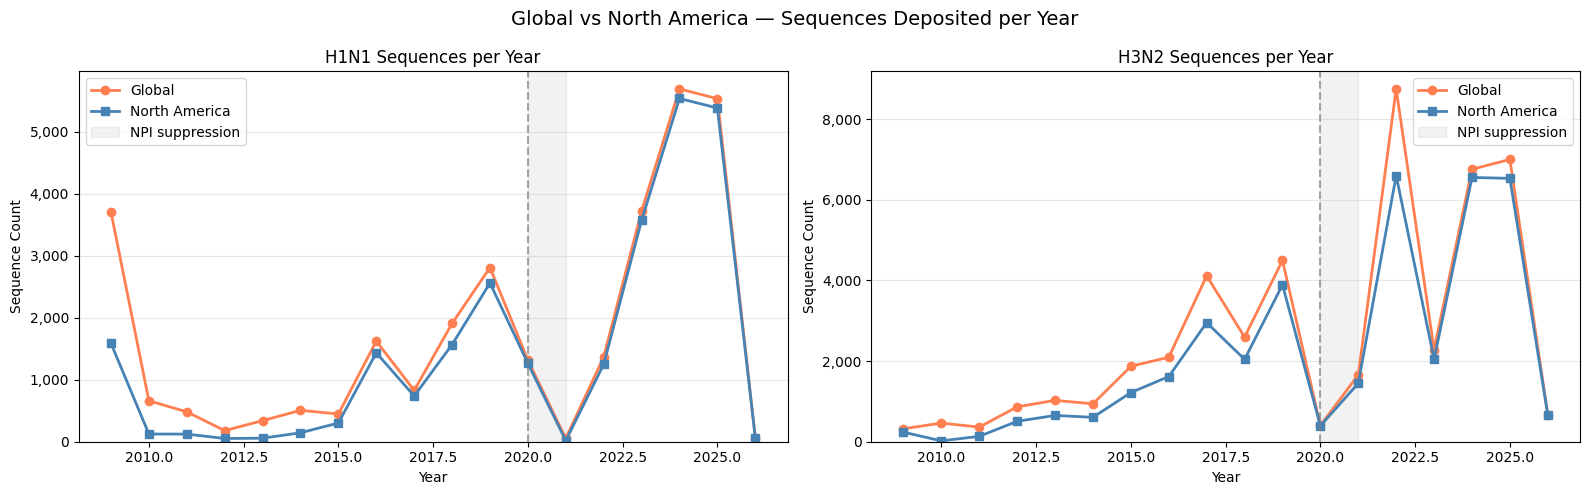

In [20]:
# sequences per year — shows the post-COVID sequencing explosion
# and non-pharmaceutical interventions (NPIs) dip
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, g_ds, na_ds) in zip(axes, [
    ('H1N1', global_h1n1, h1n1_drift),
    ('H3N2', global_h3n2, h3n2_drift)
]):
    # global (has train/test split)
    g_years = [int(y) for y in g_ds['train']['year']] + [int(y) for y in g_ds['test']['year']]
    g_counts = pd.Series(g_years).value_counts().sort_index()
    ax.plot(g_counts.index, g_counts.values, marker='o', label='Global',
            color='coral', linewidth=2)

    # NA drift — convert to list first to handle both Dataset and DatasetDict
    na_year_raw = list(na_ds['year']) if hasattr(na_ds, '__getitem__') else []
    na_years = [int(y) for y in na_year_raw]
    na_counts = pd.Series(na_years).value_counts().sort_index()
    if len(na_counts) > 0:
        ax.plot(na_counts.index, na_counts.values, marker='s', label='North America',
                color='steelblue', linewidth=2)
    else:
        print(f'Warning: {name} NA drift dataset has no year data')

    ax.axvline(x=2020, color='grey', linestyle='--', alpha=0.7)
    ax.axvspan(2020, 2021, alpha=0.1, color='grey', label='NPI suppression')
    ax.set_title(f'{name} Sequences per Year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Sequence Count')
    ax.set_ylim(bottom=0)  # counts can't be negative
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Global vs North America — Sequences Deposited per Year', fontsize=14)
plt.tight_layout()
plt.show()

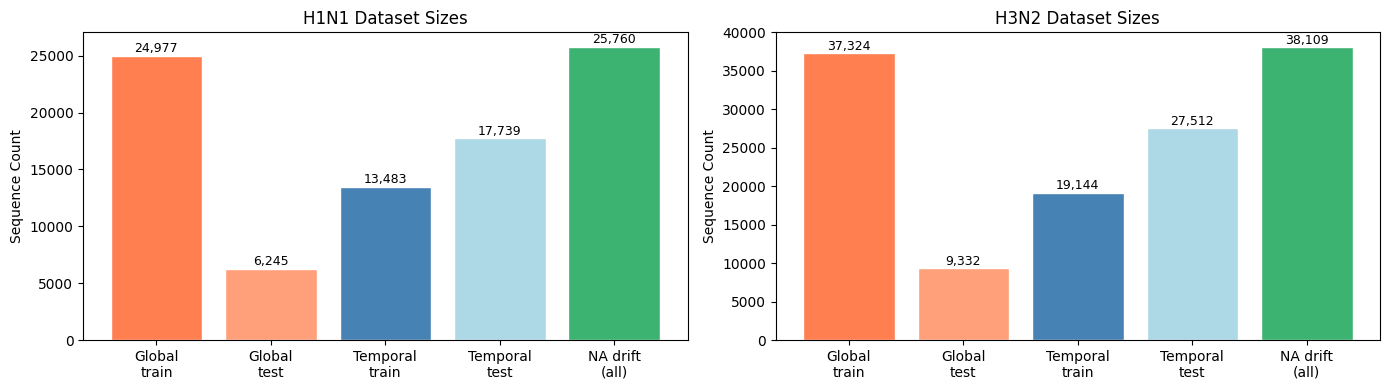

In [21]:
# train/test balance for global training sets + drift set sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, g_rand, g_temp, na_drift) in zip(axes, [
    ('H1N1', global_h1n1, global_h1n1_temp, h1n1_drift),
    ('H3N2', global_h3n2, global_h3n2_temp, h3n2_drift)
]):
    splits = {
        'Global\ntrain': len(g_rand['train']),
        'Global\ntest': len(g_rand['test']),
        'Temporal\ntrain': len(g_temp['train']),
        'Temporal\ntest': len(g_temp['test']),
        'NA drift\n(all)': len(na_drift),
    }
    bars = ax.bar(splits.keys(), splits.values(),
                  color=['coral', 'lightsalmon', 'steelblue', 'lightblue', 'mediumseagreen'],
                  edgecolor='white')
    ax.set_title(f'{name} Dataset Sizes')
    ax.set_ylabel('Sequence Count')
    ax.tick_params(axis='x', rotation=0)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()